In [1]:
import json
from pathlib import Path
from collections import defaultdict
import pandas as pd
import yaml
import numpy as np
import torch

root = Path('/Users/yuanchenwu/Desktop/ICML_SMART_BOOTSTRAP')
results_dir = root / 'results'
# pattern = 'metrics_SBM_n1000*_oracle*.json'
pattern = 'metrics_SBM*n1000*fitted*'
files = sorted(results_dir.glob(pattern))
len(files), files[:3]



(43,
 [PosixPath('/Users/yuanchenwu/Desktop/ICML_SMART_BOOTSTRAP/results/metrics_SBM_n1000_K3_sbm_separate_self_nuis-fitted_B500_a0p05_mij_1.json'),
  PosixPath('/Users/yuanchenwu/Desktop/ICML_SMART_BOOTSTRAP/results/metrics_SBM_n1000_K3_sbm_separate_self_nuis-fitted_B500_a0p05_mij_10.json'),
  PosixPath('/Users/yuanchenwu/Desktop/ICML_SMART_BOOTSTRAP/results/metrics_SBM_n1000_K3_sbm_separate_self_nuis-fitted_B500_a0p05_mij_11.json')])

In [2]:
def _normalize_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return [x]


def alpha_to_key(alpha_val: float) -> str:
    # must match run_experiment_sbm formatting: 0.05 -> alpha_0p05, 0.1 -> alpha_0p1
    s = (f"{float(alpha_val):.6f}".rstrip("0").rstrip(".")).replace(".", "p")
    return f"alpha_{s}"


def k_to_key(k_val) -> str:
    if k_val is None:
        return "default"
    return f"k_{int(k_val)}"


def get_cov_block(data: dict, *, split: str, kind: str, k_val, alpha_val: float) -> dict:
    """Return coverage dict for a particular (alpha, k, split, kind).

    New schema:
      data['coverage_by_alpha_k'][alpha_key][k_key][split][kind]

    Legacy schema fallback:
      data['coverage'][split][kind]
    """
    # New schema
    cov_all = data.get('coverage_by_alpha_k')
    if isinstance(cov_all, dict):
        a_key = alpha_to_key(alpha_val)
        k_key = k_to_key(k_val)
        entry = (cov_all.get(a_key) or {}).get(k_key) or {}
        return (entry.get(split) or {}).get(kind) or {}

    # Legacy fallback
    return data.get('coverage', {}).get(split, {}).get(kind) or {}


def load_filtered(paths, max_files=None, seed_allow=None, fit_nuisance=None):
    """Load metrics jsons and filter by seed / nuisance flag.

    Note: we no longer filter by (k, alpha) at file-selection time, because
    each json now contains ALL (alpha × k) blocks under coverage_by_alpha_k.
    """
    if seed_allow is None:
        seed_allow = set(range(1, 61))
    selected = []
    for p in paths:
        with p.open() as f:
            data = json.load(f)
        seed = data.get('train_cfg_attn', {}).get('seed')
        if seed_allow and seed not in seed_allow:
            continue
        if fit_nuisance is not None:
            if data.get('nuisance', {}).get('fit_nuisance') != fit_nuisance:
                continue
        selected.append((p, data))
        if max_files is not None and len(selected) >= max_files:
            break
    return selected


# Load files (seeds 1..60 by default)
selected_files = load_filtered(files, max_files=None, seed_allow=set(range(1, 101)), fit_nuisance=True)
print(f"Loaded {len(selected_files)} files")

# Discover k/alpha grids from bootstrap config (union across loaded files)
alpha_values = set()
k_values = set()
for _, data in selected_files:
    boot = data.get('bootstrap', {})
    for a in _normalize_list(boot.get('alpha')):
        if a is not None:
            alpha_values.add(float(a))
    ev = boot.get('eval_mask', {})
    for k in _normalize_list(ev.get('k')):
        if k is not None:
            k_values.add(int(k))

alpha_values = sorted(alpha_values)
k_values = sorted(k_values)
print(f"alpha_values={alpha_values}")
print(f"k_values={k_values}")

# Build a map keyed by (k, alpha) -> list of (path, data).
# Each file contains coverage blocks for all combinations.
selected_by_k_alpha = {(k, a): selected_files for k in k_values for a in alpha_values}
for (k_val, a_val), sel in selected_by_k_alpha.items():
    print(f"k={k_val}, alpha={a_val}: {len(sel)} files")



Loaded 43 files
alpha_values=[0.05, 0.1]
k_values=[2, 20]
k=2, alpha=0.05: 43 files
k=2, alpha=0.1: 43 files
k=20, alpha=0.05: 43 files
k=20, alpha=0.1: 43 files


In [3]:
# After the selected_by_k_alpha loop
for (k_val, a_val), sel in selected_by_k_alpha.items():
    seeds = []
    for p, data in sel:
        seed = data.get('train_cfg_attn', {}).get('seed')
        seeds.append((p.name, seed))
    # print(f"\nSeeds for k={k_val}, alpha={a_val}:")
    # for fname, seed in seeds:
    #     print(f"  {fname}: seed={seed}")



In [4]:
# Load core config
with open(root / 'config_experiment_sbm.yaml', 'r') as f:
    cfg = yaml.safe_load(f)
exp_cfg = cfg.get('experiment', {})

n = int(exp_cfg.get('n', 5000))
num_communities = int(exp_cfg.get('num_communities', 10))
p = float(exp_cfg.get('p', 0.005))
q = float(exp_cfg.get('q', 0.0005))
outcome_mode = exp_cfg.get('outcome_mode', 'separate_self')
low_dimension = bool(exp_cfg.get('low_dimension', False))
include_self_loop = outcome_mode == 'with_self'

f_type = exp_cfg.get('f_type', 'cosine')
g_type = exp_cfg.get('g_type', 'heter')
attn_temperature = float(exp_cfg.get('attn_temperature', 0.0))
# Fixed graph/covariate seed (matches run_experiment_sbm behavior)
graph_seed = int(exp_cfg.get('graph_seed', 41))

beta = float(exp_cfg.get('beta', 1.0))
alpha_treat = float(exp_cfg.get('alpha_treat', exp_cfg.get('alpha', 2.0)))
sigma = float(exp_cfg.get('sigma', 0.05))
scale = float(exp_cfg.get('scale', 5.0))
num_partition = int(exp_cfg.get('num_partition', 3))
ratio_self = float(exp_cfg.get('ratio_self', 1.0))

from addition import generate_sbm_graph, generate_covariates
from simulation import simulate_treatment, compute_outcome

cache_truth = {}


def get_truth_for_seed(seed):
    if seed in cache_truth:
        return cache_truth[seed]

    # Match run_experiment_sbm: fixed graph/covariates via graph_seed, test uses graph_seed+1.
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Train graph/covariates (fixed seed)
    np.random.seed(graph_seed)
    torch.manual_seed(graph_seed)
    A, _ = generate_sbm_graph(n=n, num_communities=num_communities, p=p, q=q, seed=graph_seed)
    X = generate_covariates(n=n, d=5, seed=graph_seed)
    A = A + np.eye(n)

    # Test graph/covariates (fixed seed + 1)
    A_test, _ = generate_sbm_graph(n=n, num_communities=num_communities, p=p, q=q, seed=graph_seed + 1)
    X_test = generate_covariates(n=n, d=5, seed=graph_seed + 1)
    A_test = A_test + np.eye(n)

    # Reseed to run-seed before treatment/outcomes (mirrors run_experiment_sbm sequence)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Train treatment/outcome
    nbrs_idx, n_train, d_local, partitions, t, e_star, treat_neighbor, treat_matrix = simulate_treatment(
        X, A, mode='train', beta=beta, alpha=alpha_treat, num_partitions=num_partition, include_self_loop=include_self_loop
    )
    W_true, spillover_true, U_0, noise, y, m_star, self_effect_true, raw_scores = compute_outcome(
        X,
        A,
        treat_matrix,
        e_star,
        n_train,
        sigma,
        scale,
        attn_temperature,
        name=f_type,
        outcome_mode=outcome_mode,
        self_name=g_type,
        t=t,
        w_self=ratio_self,
        low_dimension=low_dimension,
    )

    # Test treatment/outcome (continuing RNG state as in run_experiment_sbm)
    nbrs_idx_test, n_test, d_test, partitions_test, t_test, e_star_test, treat_neighbor_test, treat_matrix_test = simulate_treatment(
        X_test,
        A_test,
        mode='test',
        beta=beta,
        alpha=alpha_treat,
        include_self_loop=include_self_loop,
    )
    (
        W_true_test,
        spillover_true_test,
        U_0_test,
        noise_test,
        y_test,
        m_star_test,
        self_effect_true_test,
        raw_scores_test,
    ) = compute_outcome(
        X_test,
        A_test,
        treat_matrix_test,
        e_star_test,
        n_test,
        sigma,
        scale,
        attn_temperature,
        name=f_type,
        outcome_mode=outcome_mode,
        self_name=g_type,
        t=t_test,
        w_self=ratio_self,
        low_dimension=low_dimension,
    )

    cache_truth[seed] = {
        'train': {'W_true': W_true, 'raw_scores': raw_scores},
        'test': {'W_true': W_true_test, 'raw_scores': raw_scores_test},
    }
    return cache_truth[seed]

# # quick check
# a = get_truth_for_seed(41)
# "truth ready"


In [5]:
def collect_uncovered_details(selected_map, split='train', target_prefix=None):
    """Collect uncovered entries with full CI details (base/truth/band/boot stats).

    Uses the new nested schema via get_cov_block(...).
    """
    rows = []
    for (k_val, a_val), selected in selected_map.items():
        for path, data in selected:
            cov = get_cov_block(data, split=split, kind='raw_scores', k_val=k_val, alpha_val=a_val) or {}
            if not cov:
                continue
            B_total = cov.get('B_total')
            pref_key = str(target_prefix if target_prefix is not None else B_total)
            entry = (cov.get('by_prefix') or {}).get(pref_key, {})
            if not entry:
                continue
            ud_list = entry.get('uniform', {}).get('uncovered_details') or []

            # Fallback if details are absent
            if not ud_list:
                for (i, j) in entry.get('uniform', {}).get('uncovered_indices') or []:
                    rows.append({
                        'k': k_val,
                        'alpha': a_val,
                        'file': path.name,
                        'seed': data.get('train_cfg_attn', {}).get('seed'),
                        'split': split,
                        'B_prefix': entry.get('B_prefix', pref_key),
                        'i': int(i),
                        'j': int(j),
                        'base': None,
                        'truth': None,
                        'ci_lo': None,
                        'ci_hi': None,
                        'boot_mean': None,
                        'boot_std': None,
                        'band_width': None,
                        'miss_side': None,
                    })

            for ud in ud_list:
                boot_arr = ud.get('boot') or []
                rows.append({
                    'k': k_val,
                    'alpha': a_val,
                    'file': path.name,
                    'seed': data.get('train_cfg_attn', {}).get('seed'),
                    'split': split,
                    'B_prefix': entry.get('B_prefix', pref_key),
                    'i': ud['i'],
                    'j': ud['j'],
                    'base': ud.get('base'),
                    'truth': ud.get('truth'),
                    'ci_lo': ud.get('ci_lo'),
                    'ci_hi': ud.get('ci_hi'),
                    'boot_mean': float(pd.Series(boot_arr).mean()) if len(boot_arr) else None,
                    'boot_std': float(pd.Series(boot_arr).std(ddof=1)) if len(boot_arr) > 1 else (0.0 if len(boot_arr) == 1 else None),
                    'band_width': (ud.get('ci_hi') - ud.get('ci_lo')) if (ud.get('ci_hi') is not None and ud.get('ci_lo') is not None) else None,
                    'miss_side': 'above' if (ud.get('truth') is not None and ud.get('ci_hi') is not None and ud['truth'] > ud['ci_hi']) else (
                        'below' if (ud.get('truth') is not None and ud.get('ci_lo') is not None and ud['truth'] < ud['ci_lo']) else None
                    ),
                })

    return pd.DataFrame(rows)

# Use full B by default (target_prefix=None)
flat_train = collect_uncovered_details(selected_by_k_alpha, split='train', target_prefix=None)
flat_test = collect_uncovered_details(selected_by_k_alpha, split='test', target_prefix=None)

flat_train.head(), flat_test.head()



(   k  alpha                                               file  seed  split  \
 0  2   0.05  metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...    17  train   
 1  2   0.05  metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...    17  train   
 2  2   0.05  metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...    17  train   
 3  2   0.05  metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...    18  train   
 4  2   0.05  metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...    18  train   
 
    B_prefix    i    j      base     truth     ci_lo     ci_hi  boot_mean  \
 0       500   29  298  0.411768 -0.330546 -0.273503  1.097039   0.350917   
 1       500  298  710 -0.594401  0.454805 -1.528995  0.340193  -0.425198   
 2       500  620  532 -0.206896  0.760868 -1.145883  0.732091  -0.193406   
 3       500   60   83 -0.525521  0.589880 -1.630019  0.578976  -0.099712   
 4       500  247  680 -0.481602  0.478541 -1.373660  0.410456  -0.189234   
 
    boot_std  band_width miss_side  
 0  0.140609    1

In [6]:
uncovered_table = pd.concat([flat_train, flat_test], ignore_index=True)
uncovered_table

,k,alpha,file,seed,split,B_prefix,i,j,base,truth,ci_lo,ci_hi,boot_mean,boot_std,band_width,miss_side
0,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,29,298,0.411768,-0.330546,-0.273503,1.097039,0.350917,0.140609,1.370542,below
1,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,298,710,-0.594401,0.454805,-1.528995,0.340193,-0.425198,0.191767,1.869188,above
2,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,620,532,-0.206896,0.760868,-1.145883,0.732091,-0.193406,0.192668,1.877974,above
3,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,18,train,500,60,83,-0.525521,0.589880,-1.630019,0.578976,-0.099712,0.218333,2.208995,above
4,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,18,train,500,247,680,-0.481602,0.478541,-1.373660,0.410456,-0.189234,0.176338,1.784117,above
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,7,test,500,673,701,-0.119468,-0.828472,-0.824126,0.585190,-0.325293,0.137750,1.409316,below
911,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,7,test,500,888,673,0.490207,-0.504941,-0.460287,1.440701,0.180071,0.185808,1.900988,below
912,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,9,test,500,124,319,-0.403925,0.521835,-1.209735,0.401886,-0.254455,0.163625,1.611621,above
913,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,9,test,500,152,50,-0.404082,0.480400,-1.205161,0.396997,-0.367507,0.162664,1.602157,above


In [7]:
def build_mask_from_truth(W_true):
    return (W_true != 0)


def collect_raw_values(flat_df):
    rows = []
    grouped = flat_df.groupby(['k', 'alpha', 'seed', 'split'])
    for (k_val, a_val, seed, split_label), g in grouped:
        truth = get_truth_for_seed(int(seed))[split_label]
        W_true = truth['W_true']
        raw_scores = truth['raw_scores']
        mask = build_mask_from_truth(W_true)
        uncovered_set = {(int(r['i']), int(r['j'])) for _, r in g.iterrows()}
        # Uncovered
        for _, r in g.iterrows():
            i, j = int(r['i']), int(r['j'])
            rows.append({
                'k': k_val,
                'alpha': a_val,
                'file': r['file'],
                'seed': seed,
                'split': split_label,
                'B_prefix': r['B_prefix'],
                'i': i,
                'j': j,
                'type': 'uncovered',
                'raw_score': float(raw_scores[i, j]),
            })
        # Covered (masked minus uncovered)
        covered_coords = np.argwhere(mask)
        for i, j in covered_coords:
            if (int(i), int(j)) in uncovered_set:
                continue
            rows.append({
                'k': k_val,
                'alpha': a_val,
                'file': None,
                'seed': seed,
                'split': split_label,
                'B_prefix': g['B_prefix'].iloc[0],
                'i': int(i),
                'j': int(j),
                'type': 'covered',
                'raw_score': float(raw_scores[i, j]),
            })
    return pd.DataFrame(rows)

flat_all = pd.concat([flat_train, flat_test], ignore_index=True)
raw_values = collect_raw_values(flat_all)
raw_values.head()


,k,alpha,file,seed,split,B_prefix,i,j,type,raw_score
0,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,3,test,500,532,644,uncovered,0.218387
1,2,0.05,None,3,test,500,0,20,covered,-0.680661
2,2,0.05,None,3,test,500,0,125,covered,-0.134915
3,2,0.05,None,3,test,500,0,270,covered,0.310443
4,2,0.05,None,3,test,500,0,291,covered,0.252332


,type,count,mean,std,min,max
0,covered,953753,-0.002355,0.445938,-0.988440,0.991863
1,uncovered,915,0.175476,0.588303,-0.914194,0.976379


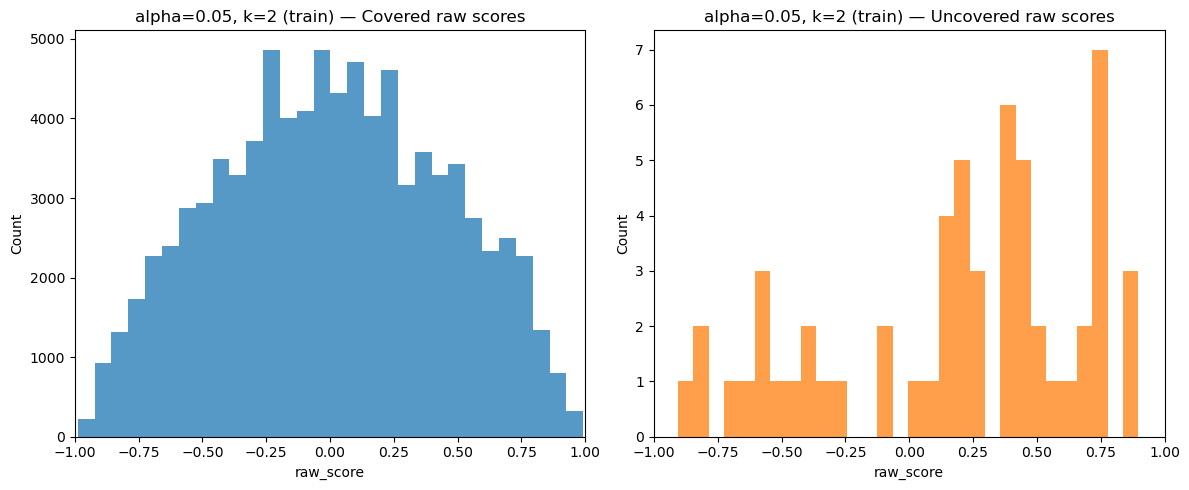

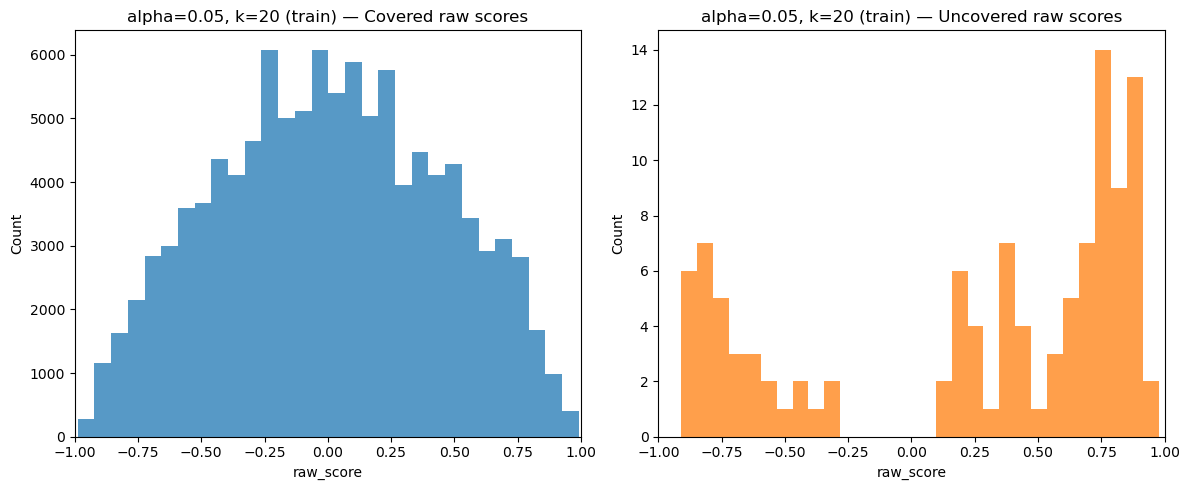

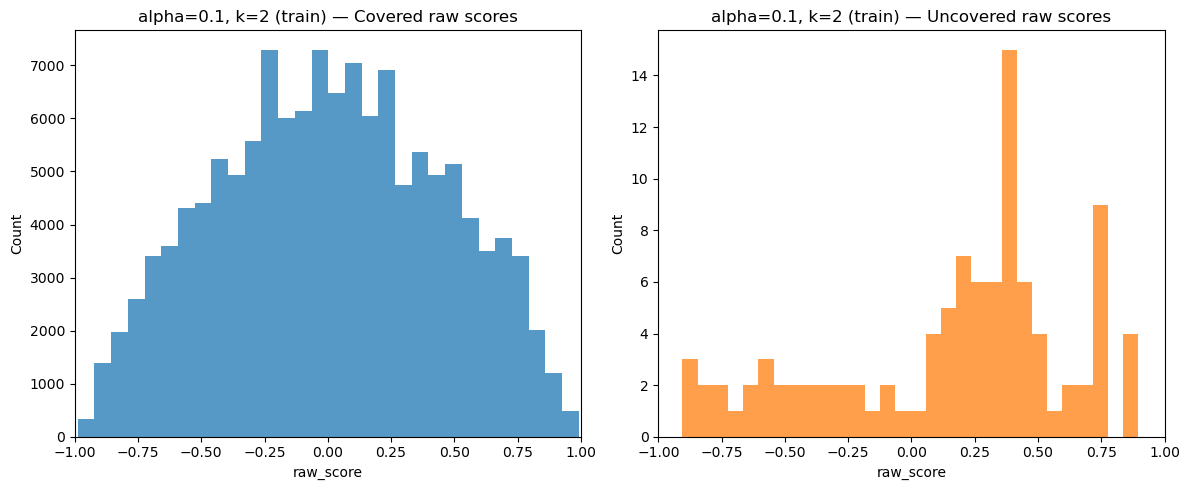

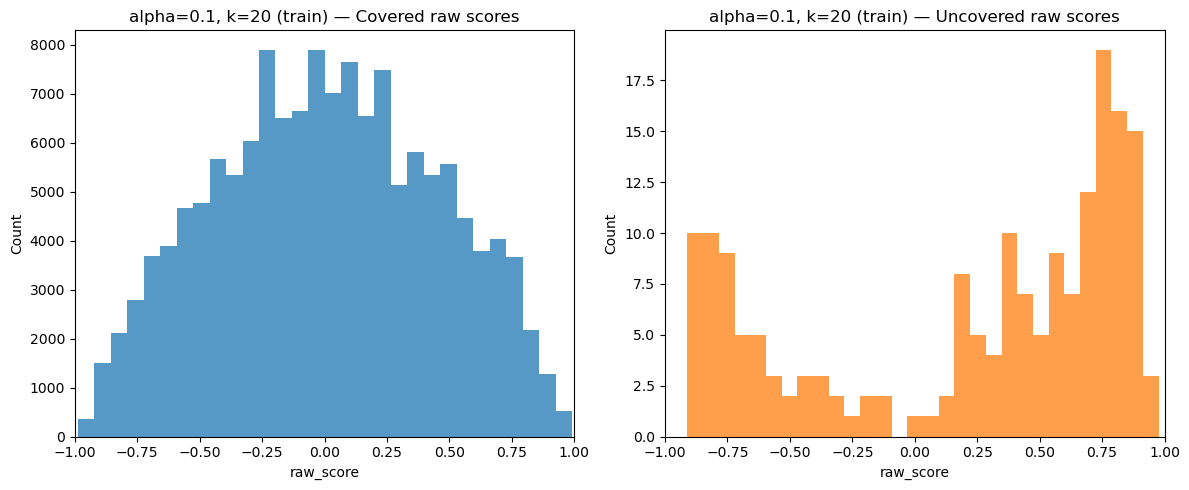

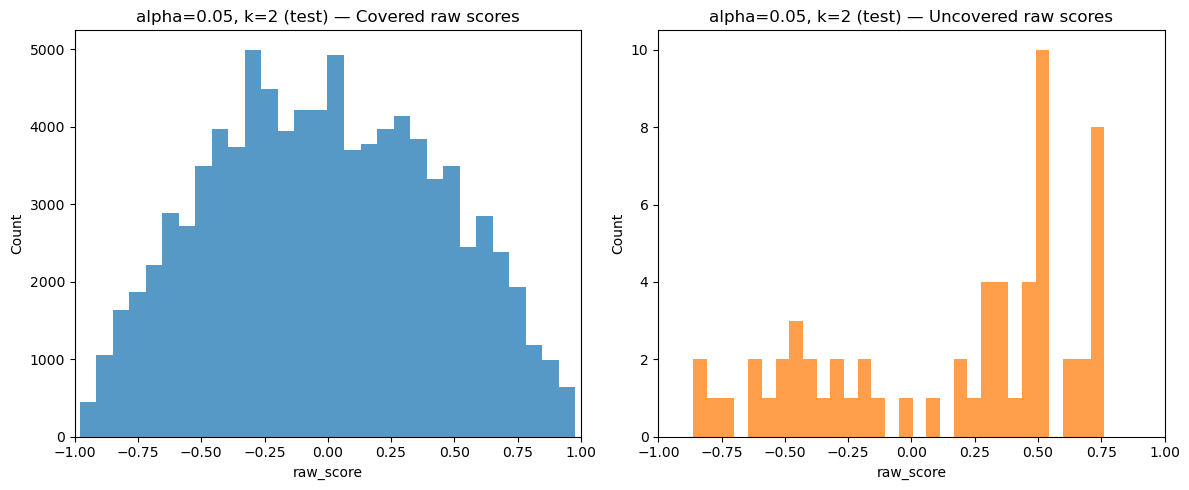

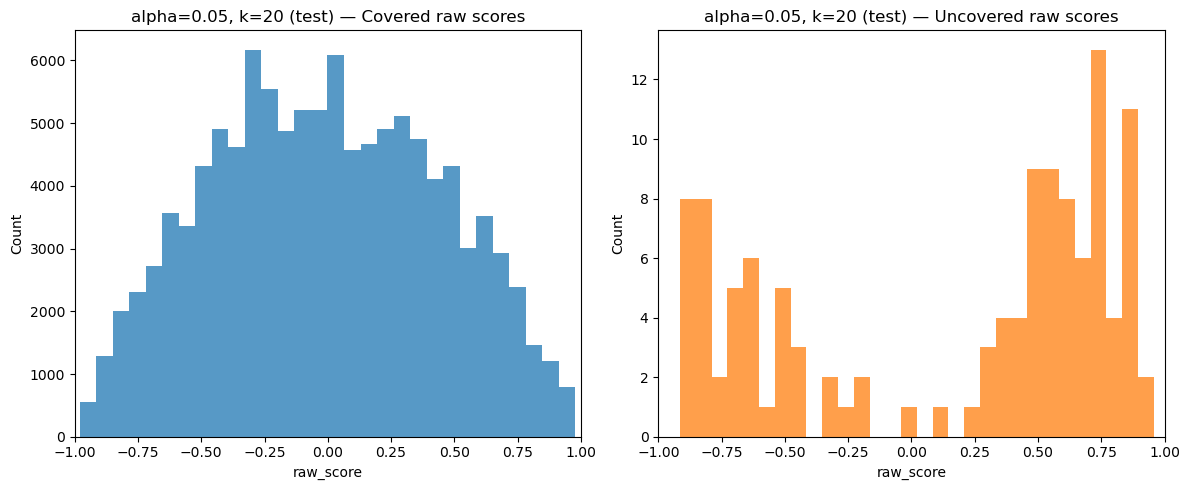

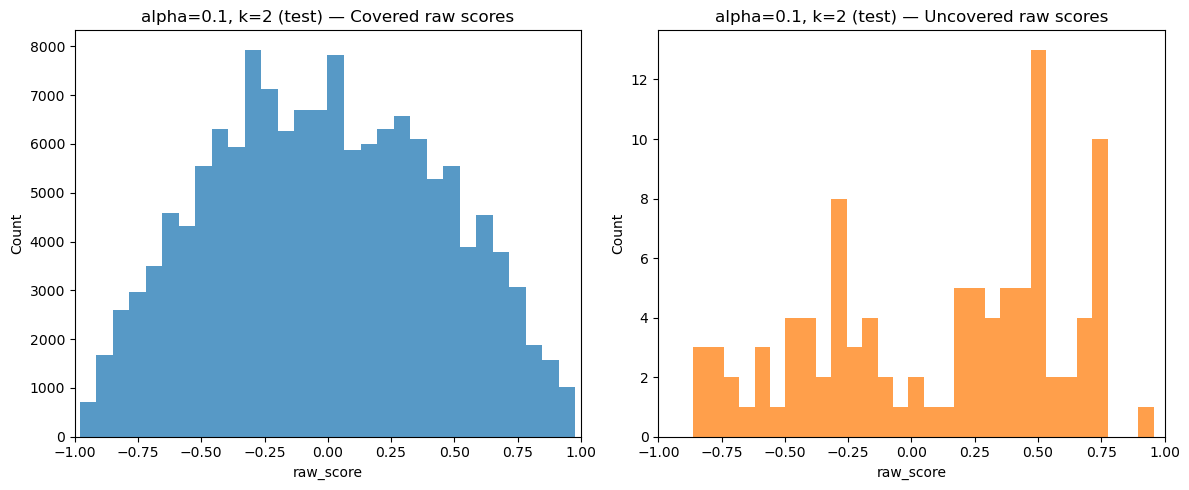

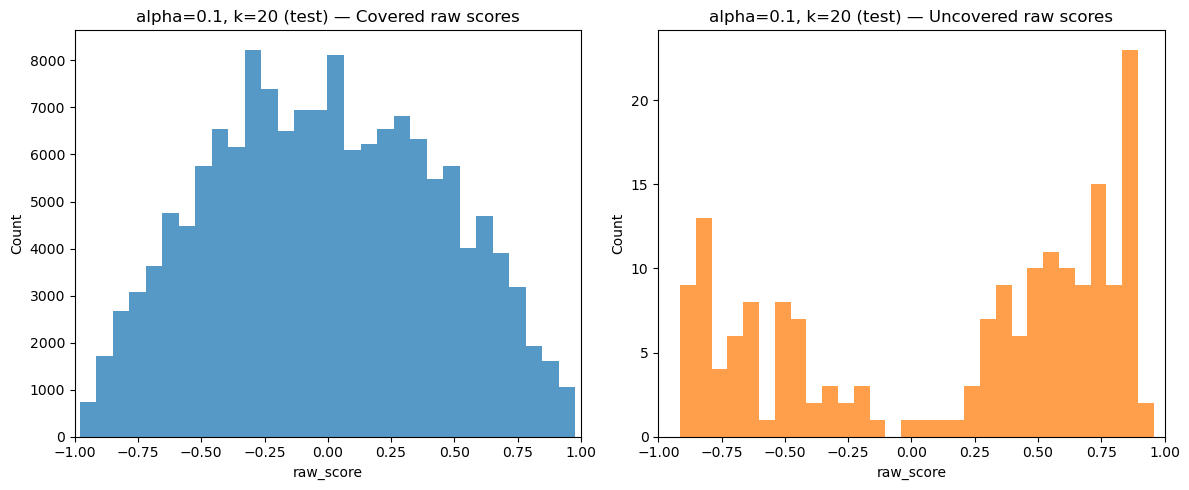

In [8]:
import matplotlib.pyplot as plt

# Summary over raw scores
summary = (
    raw_values.groupby('type')['raw_score']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .reset_index()
)
display(summary)

# Side-by-side histograms, split by k and alpha, for train and test.
# Covered/uncovered share x-limits per subplot and are clamped to at least [-1, 1].
types = ['covered', 'uncovered']
colors = {'covered': '#1f77b4', 'uncovered': '#ff7f0e'}

for split_label in ['train', 'test']:
    split_df = raw_values[raw_values['split'] == split_label]
    for a_val in sorted(split_df['alpha'].dropna().unique()):
        for k_val in sorted(split_df['k'].dropna().unique()):
            subset = split_df[(split_df['k'] == k_val) & (split_df['alpha'] == a_val)]
            if subset.empty:
                continue
            fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
            x_min = min(subset['raw_score'].min(), -1)
            x_max = max(subset['raw_score'].max(), 1)
            for idx, t in enumerate(types):
                group = subset[subset['type'] == t]
                axes[idx].hist(group['raw_score'], bins=30, color=colors[t], alpha=0.75)
                axes[idx].set_xlim([x_min, x_max])
                axes[idx].set_title(f"alpha={a_val}, k={k_val} ({split_label}) — {t.capitalize()} raw scores")
                axes[idx].set_xlabel('raw_score')
                axes[idx].set_ylabel('Count')
            plt.tight_layout()
            plt.show()


In [9]:
import numpy as np
import pandas as pd

def rebuild_covariates():
    # fixed graphs/covariates as in run_experiment_sbm
    np.random.seed(graph_seed); torch.manual_seed(graph_seed)
    _, _ = generate_sbm_graph(n=n, num_communities=num_communities, p=p, q=q, seed=graph_seed)
    X_tr = generate_covariates(n=n, d=5, seed=graph_seed)
    np.random.seed(graph_seed + 1); torch.manual_seed(graph_seed + 1)
    _, _ = generate_sbm_graph(n=n, num_communities=num_communities, p=p, q=q, seed=graph_seed + 1)
    X_te = generate_covariates(n=n, d=5, seed=graph_seed + 1)
    return X_tr, X_te

X_train_cov, X_test_cov = rebuild_covariates()

def node_norms(Xmat):
    return np.linalg.norm(Xmat, axis=1)

norms_tr = node_norms(X_train_cov)
norms_te = node_norms(X_test_cov)

# Precompute percentile ranks for norms (per split)
percentile_tr = np.searchsorted(np.sort(norms_tr), norms_tr, side='right') / len(norms_tr)
percentile_te = np.searchsorted(np.sort(norms_te), norms_te, side='right') / len(norms_te)

def summarize_uncovered_rows(df):
    rows = []
    for _, r in df.iterrows():
        split = r['split']
        i, j = int(r['i']), int(r['j'])
        norms = norms_tr if split == 'train' else norms_te
        pct = percentile_tr if split == 'train' else percentile_te
        rows.append({
            **r.to_dict(),
            'norm_i': float(norms[i]),
            'norm_j': float(norms[j]),
            'norm_pct_i': float(pct[i]),
            'norm_pct_j': float(pct[j]),
        })
    return pd.DataFrame(rows)

uncovered_with_cov = summarize_uncovered_rows(uncovered_table)
uncovered_with_cov

,k,alpha,file,seed,split,B_prefix,i,j,base,truth,ci_lo,ci_hi,boot_mean,boot_std,band_width,miss_side,norm_i,norm_j,norm_pct_i,norm_pct_j
0,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,29,298,0.411768,-0.330546,-0.273503,1.097039,0.350917,0.140609,1.370542,below,1.0,1.0,0.990,0.990
1,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,298,710,-0.594401,0.454805,-1.528995,0.340193,-0.425198,0.191767,1.869188,above,1.0,1.0,0.990,0.990
2,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,620,532,-0.206896,0.760868,-1.145883,0.732091,-0.193406,0.192668,1.877974,above,1.0,1.0,0.347,0.990
3,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,18,train,500,60,83,-0.525521,0.589880,-1.630019,0.578976,-0.099712,0.218333,2.208995,above,1.0,1.0,0.990,0.990
4,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,18,train,500,247,680,-0.481602,0.478541,-1.373660,0.410456,-0.189234,0.176338,1.784117,above,1.0,1.0,0.990,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,7,test,500,673,701,-0.119468,-0.828472,-0.824126,0.585190,-0.325293,0.137750,1.409316,below,1.0,1.0,0.983,0.983
911,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,7,test,500,888,673,0.490207,-0.504941,-0.460287,1.440701,0.180071,0.185808,1.900988,below,1.0,1.0,0.320,0.983
912,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,9,test,500,124,319,-0.403925,0.521835,-1.209735,0.401886,-0.254455,0.163625,1.611621,above,1.0,1.0,0.983,0.320
913,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,9,test,500,152,50,-0.404082,0.480400,-1.205161,0.396997,-0.367507,0.162664,1.602157,above,1.0,1.0,0.320,0.983


In [10]:
unique_pairs = (
    uncovered_with_cov
    .groupby(['i', 'j'])['split']
    .unique()
    .reset_index()
    .rename(columns={'split': 'splits'})
)
unique_pairs

,i,j,splits
0,1,294,[train]
1,12,184,[test]
2,15,135,[test]
3,27,478,[test]
4,28,329,[train]
...,...,...,...
332,986,762,[test]
333,989,603,[test]
334,990,320,[train]
335,992,271,[train]


In [11]:
# Compute node degrees for train/test graphs (fixed seeds)
def rebuild_graphs():
    np.random.seed(graph_seed); torch.manual_seed(graph_seed)
    A_tr, _ = generate_sbm_graph(n=n, num_communities=num_communities, p=p, q=q, seed=graph_seed)
    A_tr = A_tr + np.eye(n)
    np.random.seed(graph_seed + 1); torch.manual_seed(graph_seed + 1)
    A_te, _ = generate_sbm_graph(n=n, num_communities=num_communities, p=p, q=q, seed=graph_seed + 1)
    A_te = A_te + np.eye(n)
    return A_tr, A_te

A_train_deg, A_test_deg = rebuild_graphs()
deg_train = A_train_deg.sum(axis=1)
deg_test = A_test_deg.sum(axis=1)
avg_deg_train = deg_train.mean()
avg_deg_test = deg_test.mean()

def add_degrees(df):
    rows = []
    for _, r in df.iterrows():
        split = r['split']
        i, j = int(r['i']), int(r['j'])
        deg_i = deg_train[i] if split == 'train' else deg_test[i]
        deg_j = deg_train[j] if split == 'train' else deg_test[j]
        rows.append({**r.to_dict(),
                     'deg_i': float(deg_i),
                     'deg_j': float(deg_j),
                     'avg_deg_split': float(avg_deg_train if split == 'train' else avg_deg_test)})
    return pd.DataFrame(rows)

uncovered_with_deg = add_degrees(uncovered_table)
uncovered_with_deg

,k,alpha,file,seed,split,B_prefix,i,j,base,truth,ci_lo,ci_hi,boot_mean,boot_std,band_width,miss_side,deg_i,deg_j,avg_deg_split
0,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,29,298,0.411768,-0.330546,-0.273503,1.097039,0.350917,0.140609,1.370542,below,4.0,7.0,6.404
1,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,298,710,-0.594401,0.454805,-1.528995,0.340193,-0.425198,0.191767,1.869188,above,7.0,9.0,6.404
2,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,17,train,500,620,532,-0.206896,0.760868,-1.145883,0.732091,-0.193406,0.192668,1.877974,above,4.0,10.0,6.404
3,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,18,train,500,60,83,-0.525521,0.589880,-1.630019,0.578976,-0.099712,0.218333,2.208995,above,7.0,8.0,6.404
4,2,0.05,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,18,train,500,247,680,-0.481602,0.478541,-1.373660,0.410456,-0.189234,0.176338,1.784117,above,5.0,5.0,6.404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,7,test,500,673,701,-0.119468,-0.828472,-0.824126,0.585190,-0.325293,0.137750,1.409316,below,9.0,4.0,6.268
911,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,7,test,500,888,673,0.490207,-0.504941,-0.460287,1.440701,0.180071,0.185808,1.900988,below,13.0,9.0,6.268
912,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,9,test,500,124,319,-0.403925,0.521835,-1.209735,0.401886,-0.254455,0.163625,1.611621,above,10.0,11.0,6.268
913,20,0.10,metrics_SBM_n1000_K3_sbm_separate_self_nuis-fi...,9,test,500,152,50,-0.404082,0.480400,-1.205161,0.396997,-0.367507,0.162664,1.602157,above,8.0,6.0,6.268


In [12]:
from collections import defaultdict
import pandas as pd
import numpy as np  # if not already imported


def collect_uniform_all_covered_raw(selected_map, split='train'):
    rows = []
    for (k_val, a_val), selected_list in selected_map.items():
        by_prefix = defaultdict(lambda: defaultdict(list))
        for path, data in selected_list:
            raw = get_cov_block(data, split=split, kind='raw_scores', k_val=k_val, alpha_val=a_val) or {}
            bp = raw.get('by_prefix', {})
            for prefix, entry in bp.items():
                uniform = entry.get('uniform', {})
                if 'all_covered' in uniform:
                    by_prefix[prefix]['all_covered'].append(uniform['all_covered'])
                if 'covered_count' in uniform:
                    by_prefix[prefix]['covered_count'].append(uniform['covered_count'])
                if 'n_mask' in uniform:
                    by_prefix[prefix]['n_mask'].append(uniform['n_mask'])

        for prefix, buckets in sorted(by_prefix.items(), key=lambda x: int(x[0])):
            n = len(buckets['all_covered'])
            rows.append({
                'k': k_val,
                'alpha': a_val,
                'B_prefix': int(prefix),
                'count': n,
                'all_covered_mean': sum(buckets['all_covered']) / n if n else float('nan'),
                'covered_count_mean': sum(buckets['covered_count']) / n if n else float('nan'),
                'n_mask_mean': sum(buckets['n_mask']) / n if n else float('nan'),
            })

    return pd.DataFrame(rows)


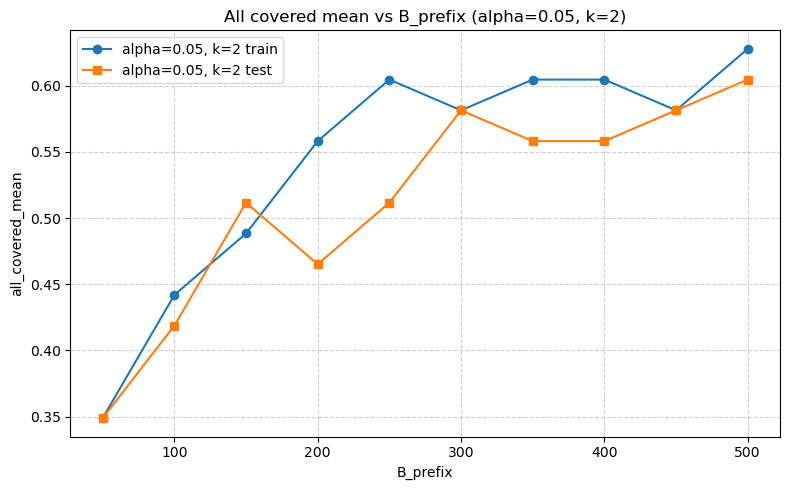

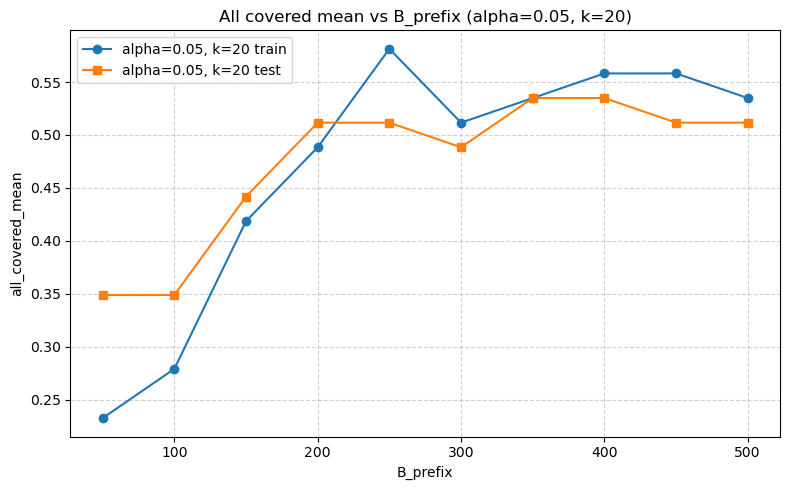

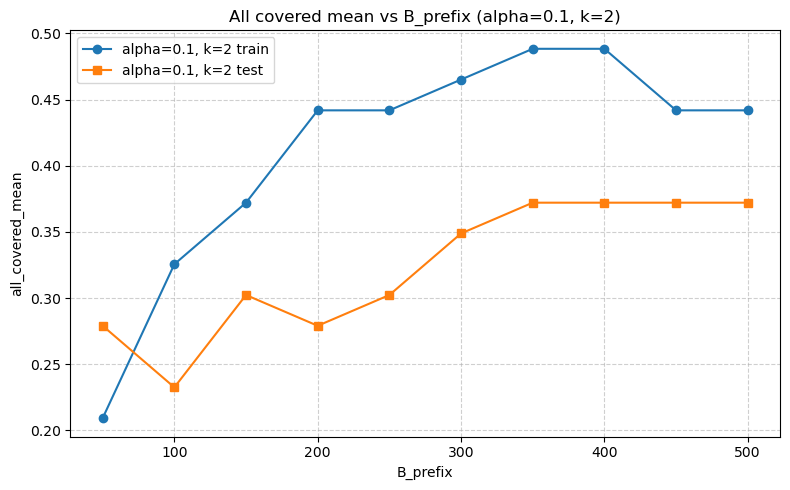

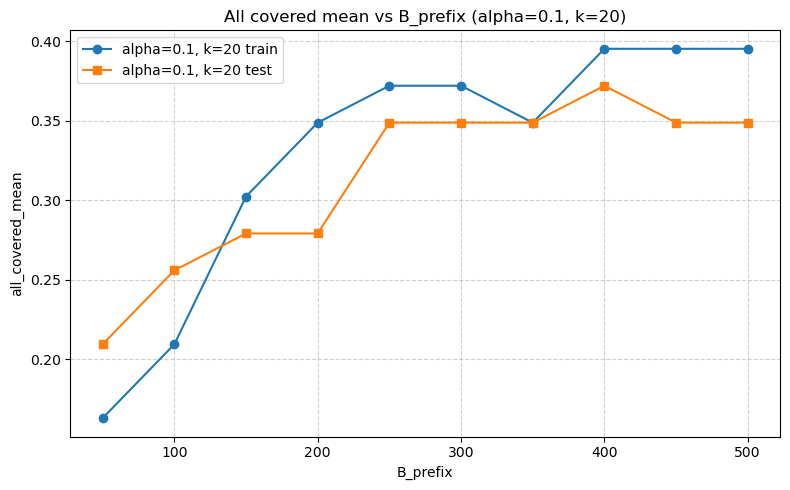

In [13]:
train_df = collect_uniform_all_covered_raw(selected_by_k_alpha, split='train')
test_df  = collect_uniform_all_covered_raw(selected_by_k_alpha, split='test')

for a_val in sorted(train_df['alpha'].dropna().unique()):
    for k_val in sorted(train_df['k'].dropna().unique()):
        t_df = train_df[(train_df['k'] == k_val) & (train_df['alpha'] == a_val)]
        te_df = test_df[(test_df['k'] == k_val) & (test_df['alpha'] == a_val)]
        if t_df.empty and te_df.empty:
            continue
        fig, ax = plt.subplots(figsize=(8, 5))
        if not t_df.empty:
            ax.plot(t_df['B_prefix'], t_df['all_covered_mean'], marker='o', label=f'alpha={a_val}, k={k_val} train')
        if not te_df.empty:
            ax.plot(te_df['B_prefix'], te_df['all_covered_mean'], marker='s', label=f'alpha={a_val}, k={k_val} test')
        ax.set_xlabel('B_prefix')
        ax.set_ylabel('all_covered_mean')
        ax.set_title(f'All covered mean vs B_prefix (alpha={a_val}, k={k_val})')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

In [15]:
train_df = collect_uniform_all_covered_raw(selected_by_k_alpha, split='train')
test_df  = collect_uniform_all_covered_raw(selected_by_k_alpha, split='test')

for a_val in sorted(train_df['alpha'].dropna().unique()):
    for k_val in sorted(train_df['k'].dropna().unique()):
        t_df = train_df[(train_df['k'] == k_val) & (train_df['alpha'] == a_val)]
        te_df = test_df[(test_df['k'] == k_val) & (test_df['alpha'] == a_val)]
        print(f"alpha={a_val}, k={k_val} train:")
        display(t_df)
        print(f"alpha={a_val}, k={k_val} test:")
        display(te_df)


alpha=0.05, k=2 train:


,k,alpha,B_prefix,count,all_covered_mean,covered_count_mean,n_mask_mean
0,2,0.05,50,43,0.348837,1975.372093,1978.0
1,2,0.05,100,43,0.441860,1975.651163,1978.0
2,2,0.05,150,43,0.488372,1976.139535,1978.0
3,2,0.05,200,43,0.558140,1976.441860,1978.0
4,2,0.05,250,43,0.604651,1976.511628,1978.0
5,2,0.05,300,43,0.581395,1976.488372,1978.0
6,2,0.05,350,43,0.604651,1976.651163,1978.0
7,2,0.05,400,43,0.604651,1976.674419,1978.0
8,2,0.05,450,43,0.581395,1976.651163,1978.0
9,2,0.05,500,43,0.627907,1976.674419,1978.0


alpha=0.05, k=2 test:


,k,alpha,B_prefix,count,all_covered_mean,covered_count_mean,n_mask_mean
0,2,0.05,50,43,0.348837,1968.441860,1971.0
1,2,0.05,100,43,0.418605,1968.627907,1971.0
2,2,0.05,150,43,0.511628,1969.279070,1971.0
3,2,0.05,200,43,0.465116,1969.139535,1971.0
4,2,0.05,250,43,0.511628,1969.302326,1971.0
5,2,0.05,300,43,0.581395,1969.465116,1971.0
6,2,0.05,350,43,0.558140,1969.534884,1971.0
7,2,0.05,400,43,0.558140,1969.534884,1971.0
8,2,0.05,450,43,0.581395,1969.534884,1971.0
9,2,0.05,500,43,0.604651,1969.581395,1971.0


alpha=0.05, k=20 train:


...

,k,alpha,B_prefix,count,all_covered_mean,covered_count_mean,n_mask_mean
10,2,0.1,50,43,0.279070,1967.093023,1971.0
11,2,0.1,100,43,0.232558,1967.720930,1971.0
12,2,0.1,150,43,0.302326,1968.186047,1971.0
13,2,0.1,200,43,0.279070,1968.209302,1971.0
14,2,0.1,250,43,0.302326,1968.348837,1971.0
15,2,0.1,300,43,0.348837,1968.418605,1971.0
16,2,0.1,350,43,0.372093,1968.604651,1971.0
17,2,0.1,400,43,0.372093,1968.767442,1971.0
18,2,0.1,450,43,0.372093,1968.697674,1971.0
19,2,0.1,500,43,0.372093,1968.651163,1971.0


alpha=0.1, k=20 train:


,k,alpha,B_prefix,count,all_covered_mean,covered_count_mean,n_mask_mean
30,20,0.1,50,43,0.162791,5396.162791,5404.0
31,20,0.1,100,43,0.209302,5397.534884,5404.0
32,20,0.1,150,43,0.302326,5398.441860,5404.0
33,20,0.1,200,43,0.348837,5398.651163,5404.0
34,20,0.1,250,43,0.372093,5399.511628,5404.0
35,20,0.1,300,43,0.372093,5399.488372,5404.0
36,20,0.1,350,43,0.348837,5399.651163,5404.0
37,20,0.1,400,43,0.395349,5399.767442,5404.0
38,20,0.1,450,43,0.395349,5399.790698,5404.0
39,20,0.1,500,43,0.395349,5399.790698,5404.0


alpha=0.1, k=20 test:


,k,alpha,B_prefix,count,all_covered_mean,covered_count_mean,n_mask_mean
30,20,0.1,50,43,0.209302,5260.302326,5268.0
31,20,0.1,100,43,0.255814,5261.465116,5268.0
32,20,0.1,150,43,0.279070,5262.534884,5268.0
33,20,0.1,200,43,0.279070,5262.976744,5268.0
34,20,0.1,250,43,0.348837,5263.441860,5268.0
35,20,0.1,300,43,0.348837,5263.627907,5268.0
36,20,0.1,350,43,0.348837,5263.837209,5268.0
37,20,0.1,400,43,0.372093,5263.813953,5268.0
38,20,0.1,450,43,0.348837,5263.837209,5268.0
39,20,0.1,500,43,0.348837,5263.697674,5268.0
